# Autoencoders on MNIST

An **autoencoder** is a neural network trained to **reconstruct its own input**. It consists of two parts:

- **Encoder** `f(x) = z` — compresses the input `x` into a low-dimensional *latent code* `z`.
- **Decoder** `g(z) = x̂` — reconstructs the input from the latent code.

The model is trained to minimize the reconstruction error between `x` and `x̂`:

$$\mathcal{L}(x, \hat{x}) = \| x - \hat{x} \|^2$$

## Why does this work?

The **bottleneck** — the latent code `z` is much smaller than the input — forces the network to *throw information away* and keep only what is most useful for reconstruction. What survives is a compact representation of the data.

## What are autoencoders good for?

- **Dimensionality reduction** — like a non-linear PCA.
- **Denoising** — train on `(noisy_x, clean_x)` pairs.
- **Anomaly detection** — inputs that reconstruct poorly are likely anomalous.
- **Pretraining / representation learning** — the encoder can be reused for downstream tasks.
- **Generation** (with extensions like VAEs) — sample `z` and decode.

## Architecture used here

```
          ENCODER                               DECODER
x (784) → 128 → 64 → 12 → z (3) → 12 → 64 → 128 → x̂ (784)
   ReLU everywhere except the last decoder layer, which uses Sigmoid.
```

We use a **3-dimensional bottleneck** on purpose: it is aggressive enough to force the model to really compress the digits, and small enough that we can later **visualize the entire latent space in 3D**.

## 1. Setup

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3D projection

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

# Auto-detect device: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 2. Data — MNIST

`transforms.ToTensor()` converts the PIL image to a `(1, 28, 28)` tensor with values in `[0, 1]`. Because pixel values are bounded in `[0, 1]`, the decoder ends with a **Sigmoid** and we use **MSE** (or BCE) as the reconstruction loss.

We split the training set into train / validation so we can monitor whether the autoencoder is actually learning to generalize (a model that just memorizes train images is not doing representation learning).

In [2]:
transform = transforms.ToTensor()

full_train = torchvision.datasets.MNIST(root="./data", train=True,  transform=transform, download=True)
test_set   = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# 90/10 train/val split
val_size = 6000
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set):>6}   Val: {len(val_set):>6}   Test: {len(test_set):>6}")

Train:  54000   Val:   6000   Test:  10000


## 3. The model

We define the **encoder** and **decoder** as `nn.Sequential` blocks and compose them in `forward()`. The bottleneck dimension is a constructor argument so students can easily experiment with compressing more or less aggressively.

### Design choices, briefly

- **Symmetric architecture**: the decoder mirrors the encoder. This is a convention, not a requirement.
- **ReLU hidden activations**: standard, avoids vanishing gradients in this shallow network.
- **Sigmoid output**: squashes the reconstruction into `[0, 1]` to match the pixel range.
- **No batch-norm / dropout**: keeps the mapping deterministic so reconstructions are stable for visualization.

In [3]:
class Autoencoder(nn.Module):
    """Fully-connected MNIST autoencoder with a configurable bottleneck.

    Parameters
    ----------
    latent_dim : int
        Size of the bottleneck vector `z`. Smaller = more compression.
    """

    def __init__(self, latent_dim=3):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),  # pixel values live in [0, 1]
        )

    def encode(self, x):
        """Input (B, 1, 28, 28) or (B, 784) -> latent (B, latent_dim)."""
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        """Latent (B, latent_dim) -> image (B, 1, 28, 28)."""
        x_recon = self.decoder(z)
        return x_recon.view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

In [4]:
LATENT_DIM = 3

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)

Total trainable parameters: 219,891


## 4. Training

A few things worth pointing out:

- We accumulate the loss across all batches and divide by sample count — this gives a **per-sample average loss** which is comparable across epochs and across train/val (the batches can differ in size).
- `model.train()` / `model.eval()` matter in general even though this particular model has no dropout or batch-norm — it is good practice to set the mode explicitly.
- `torch.no_grad()` during validation saves memory and compute (no autograd graph).
- We track **per-epoch time** and **total training time**.

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one pass over `loader`. If `optimizer` is None, run in eval/no-grad mode.

    Returns the average per-sample reconstruction loss.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    n_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for imgs, _ in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, imgs)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs = imgs.size(0)
            running_loss += loss.item() * bs
            n_samples    += bs

    return running_loss / n_samples

In [6]:
NUM_EPOCHS = 10

train_losses = []
val_losses   = []
epoch_times  = []

total_start = time.time()
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = run_epoch(model, train_loader, criterion, optimizer)
    val_loss   = run_epoch(model, val_loader,   criterion, optimizer=None)

    epoch_time = time.time() - epoch_start
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch + 1:2d}/{NUM_EPOCHS}   "
          f"train: {train_loss:.4f}   val: {val_loss:.4f}   "
          f"time: {epoch_time:.1f}s")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s   (mean per epoch: {total_time / NUM_EPOCHS:.1f}s)")

Epoch  1/10   train: 0.0702   val: 0.0556   time: 5.6s
Epoch  2/10   train: 0.0520   val: 0.0469   time: 2.5s
Epoch  3/10   train: 0.0442   val: 0.0424   time: 2.5s
Epoch  4/10   train: 0.0413   val: 0.0405   time: 2.5s
Epoch  5/10   train: 0.0397   val: 0.0391   time: 2.5s
Epoch  6/10   train: 0.0385   val: 0.0382   time: 2.5s
Epoch  7/10   train: 0.0377   val: 0.0375   time: 2.5s
Epoch  8/10   train: 0.0370   val: 0.0369   time: 2.5s
Epoch  9/10   train: 0.0365   val: 0.0364   time: 2.7s
Epoch 10/10   train: 0.0360   val: 0.0363   time: 2.6s

Total training time: 28.4s   (mean per epoch: 2.8s)


### Loss curves

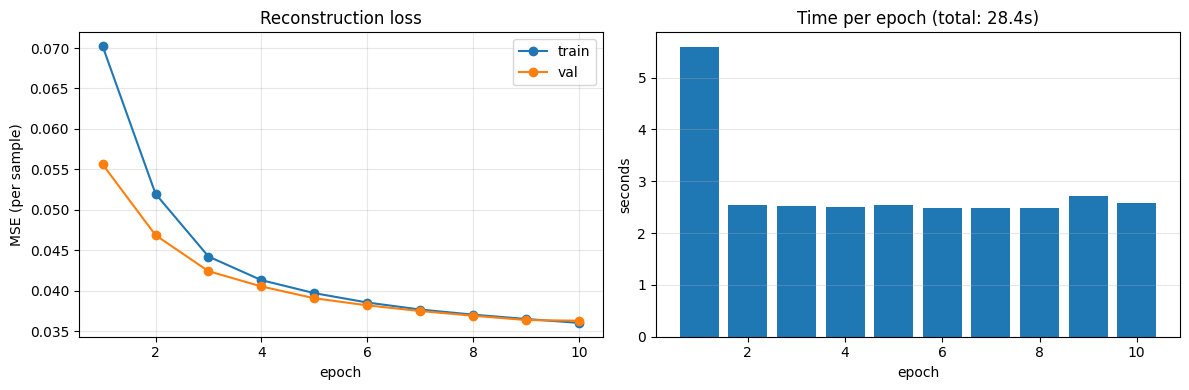

In [7]:
fig, (ax_loss, ax_time) = plt.subplots(1, 2, figsize=(12, 4))

epochs = np.arange(1, NUM_EPOCHS + 1)
ax_loss.plot(epochs, train_losses, marker="o", label="train")
ax_loss.plot(epochs, val_losses,   marker="o", label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("MSE (per sample)")
ax_loss.set_title("Reconstruction loss")
ax_loss.legend()
ax_loss.grid(alpha=0.3)

ax_time.bar(epochs, epoch_times)
ax_time.set_xlabel("epoch")
ax_time.set_ylabel("seconds")
ax_time.set_title(f"Time per epoch (total: {total_time:.1f}s)")
ax_time.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 5. Visualize reconstructions

For each of the first 10 digits in a batch, we show the original image on top and the reconstruction on the bottom. With a 3-D bottleneck, reconstructions will be recognizable but blurry — this is expected: we are compressing each 784-pixel image into just 3 numbers.

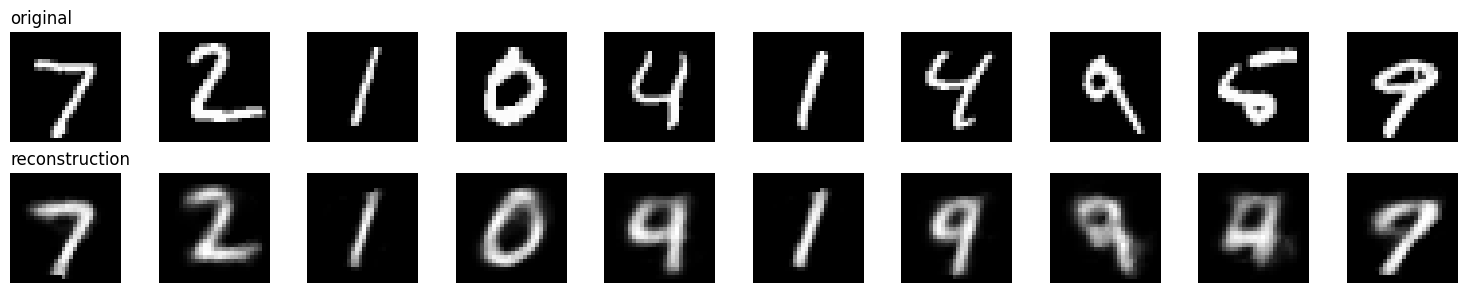

In [8]:
def show_reconstructions(model, loader, n=10):
    """Display n original images next to their reconstructions."""
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(device)
    with torch.no_grad():
        recon = model(imgs)

    imgs  = imgs.cpu().view(-1, 28, 28)
    recon = recon.cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(imgs[i],  cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recon[i], cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_title("original",      loc="left")
    axes[1, 0].set_title("reconstruction", loc="left")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=10)

## 6. Visualize the latent space

Because our bottleneck is 3-D, we can literally **plot the entire latent space** as a 3-D scatter. We encode a bunch of test images, colour each point by its true digit class, and look for structure:

- If the autoencoder learned semantically meaningful features, **points of the same digit will cluster together**.
- Classes that look similar to each other (e.g. 4 and 9, or 3 and 8) often end up close in latent space.

Remember: the autoencoder **was never given the digit labels during training**. Any class structure we see emerges purely from the reconstruction objective.

In [9]:
def encode_dataset(model, loader, max_samples=5000):
    """Encode up to `max_samples` images and return (latents, labels)."""
    model.eval()
    zs, ys = [], []
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            z = model.encode(imgs).cpu().numpy()
            zs.append(z)
            ys.append(labels.numpy())
            total += len(labels)
            if total >= max_samples:
                break
    return np.concatenate(zs)[:max_samples], np.concatenate(ys)[:max_samples]

latents, labels = encode_dataset(model, test_loader, max_samples=5000)
print(f"Latent array: {latents.shape}   Labels: {labels.shape}")

Latent array: (5000, 3)   Labels: (5000,)


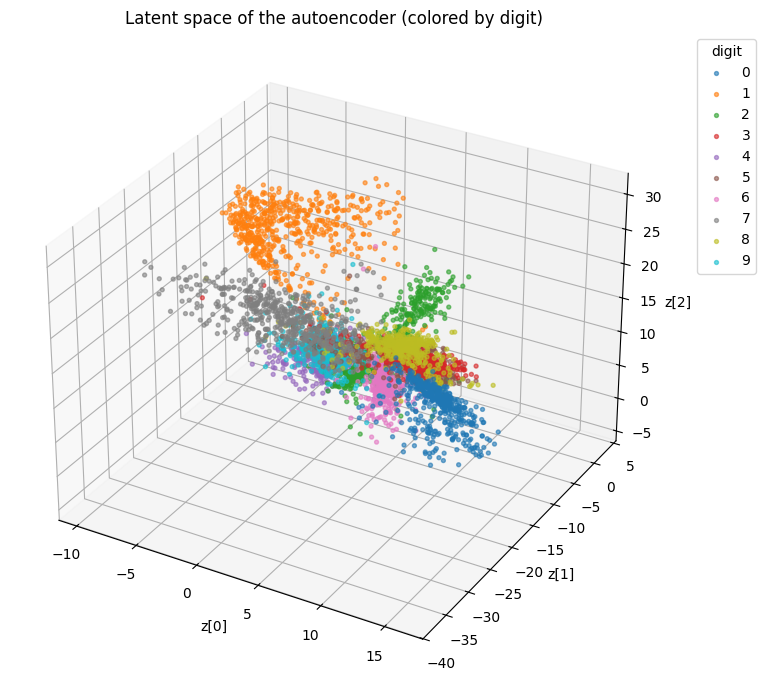

In [10]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab10")
for digit in range(10):
    mask = labels == digit
    ax.scatter(
        latents[mask, 0], latents[mask, 1], latents[mask, 2],
        s=8, alpha=0.6, color=cmap(digit), label=str(digit),
    )

ax.set_xlabel("z[0]")
ax.set_ylabel("z[1]")
ax.set_zlabel("z[2]")
ax.set_title("Latent space of the autoencoder (colored by digit)")
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), title="digit")
plt.tight_layout()
plt.show()

## 7. Latent-space interpolation

One of the most intuitive demonstrations that the latent space is *meaningful* is a **linear interpolation** between two points. We pick two images, encode them to get `z_a` and `z_b`, and decode points along the straight line between them:

$$z_t = (1 - t) \cdot z_a + t \cdot z_b, \quad t \in [0, 1]$$

If the latent space is smooth, the decoded images should morph gradually from one digit to the other, rather than jumping abruptly.

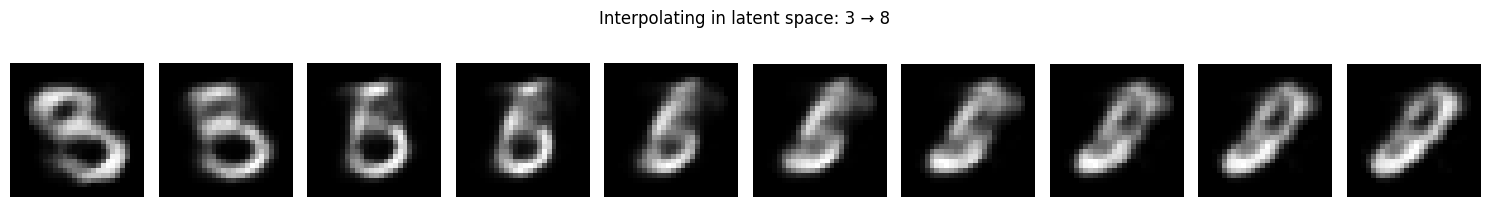

In [11]:
def interpolate(model, img_a, img_b, steps=10):
    """Linearly interpolate in latent space between two images."""
    model.eval()
    with torch.no_grad():
        z_a = model.encode(img_a.unsqueeze(0).to(device))
        z_b = model.encode(img_b.unsqueeze(0).to(device))
        ts = torch.linspace(0, 1, steps, device=device).view(-1, 1)
        zs = (1 - ts) * z_a + ts * z_b
        decoded = model.decode(zs).cpu().view(-1, 28, 28)
    return decoded

# Pick two images from different classes
all_imgs, all_labels = next(iter(test_loader))
img_a = all_imgs[(all_labels == 3).nonzero(as_tuple=True)[0][0]]
img_b = all_imgs[(all_labels == 8).nonzero(as_tuple=True)[0][0]]

morph = interpolate(model, img_a, img_b, steps=10)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(morph[i], cmap="gray")
    ax.axis("off")
fig.suptitle("Interpolating in latent space: 3 → 8", y=1.02)
plt.tight_layout()
plt.show()

## 8. Sampling from the latent space

A plain autoencoder is **not** a generative model in the strict sense — the latent space is *not constrained* to follow a known distribution, so we cannot just draw `z ~ N(0, I)` and expect good images. But we can still try: sample `z` vectors from the **range actually covered by encoded training data**, decode them, and see what comes out.

This is one of the motivations for the **Variational Autoencoder (VAE)**, which explicitly forces the latent distribution to be close to a standard Gaussian and therefore supports clean sampling.

Observed latent range per dim:
  z[0]: [-9.64, +16.08]
  z[1]: [-37.18, +2.69]
  z[2]: [-3.99, +30.47]


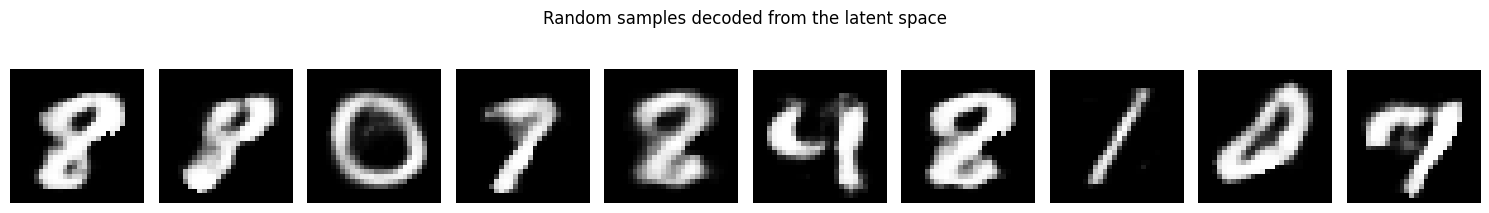

In [12]:
# Sample uniformly inside the bounding box of observed latents
z_min = latents.min(axis=0)
z_max = latents.max(axis=0)
print(f"Observed latent range per dim:")
for d in range(LATENT_DIM):
    print(f"  z[{d}]: [{z_min[d]:+.2f}, {z_max[d]:+.2f}]")

n_samples = 10
rng = np.random.default_rng(42)
z_samples = rng.uniform(z_min, z_max, size=(n_samples, LATENT_DIM)).astype(np.float32)

model.eval()
with torch.no_grad():
    generated = model.decode(torch.from_numpy(z_samples).to(device)).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated[i], cmap="gray")
    ax.axis("off")
fig.suptitle("Random samples decoded from the latent space", y=1.05)
plt.tight_layout()
plt.show()

## 9. Takeaways and things to try next

- The autoencoder compresses each 784-pixel digit into just **3 numbers** and still produces recognizable reconstructions — the bottleneck is doing real work.
- The latent space, despite being trained **without any labels**, organizes digits into roughly class-consistent clusters.
- Linear interpolation produces smooth morphs — evidence that the decoder is locally smooth in latent space.
- Random sampling in the bottleneck gives blurry, sometimes not-quite-digit results. Clean sampling is what VAEs are designed to fix.

### Exercises

1. **Change the bottleneck size.** Try `latent_dim = 2` (plottable on a flat scatter) and `latent_dim = 32`. How does reconstruction quality change? How does latent structure change?
2. **Swap MSE for BCE.** `nn.BCELoss()` is a natural choice for `[0, 1]`-valued pixels. Does training become faster or more stable?
3. **Turn it into a denoising autoencoder.** Add Gaussian noise to the inputs but keep the *clean* images as the reconstruction target. The model learns to remove noise.
4. **Use the encoder as a feature extractor.** Freeze the trained encoder, put a small `Linear` classifier on top of `z`, and train only the classifier on MNIST labels. Compare accuracy vs a classifier trained from scratch.